In [1]:
import StimCircuits.stimcircuits.surface_code as sc
import simulation as sim

In [2]:
params = {
    "code_task": "surface_code:unrotated_memory_x",
    "rounds": 5,
    "distance": 3,
    "after_clifford_depolarization": 0.001,
    "before_round_data_depolarization": 0.002,
    "before_measure_flip_probability": 0.003,
    "after_reset_flip_probability": 0.004,
}

In [3]:
circuit = sc.generate_circuit(**params)

In [4]:
print(repr(circuit))

stim.Circuit('''
    QUBIT_COORDS(0, 0) 0
    QUBIT_COORDS(1, 0) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 0) 3
    QUBIT_COORDS(4, 0) 4
    QUBIT_COORDS(0, 1) 5
    QUBIT_COORDS(1, 1) 6
    QUBIT_COORDS(2, 1) 7
    QUBIT_COORDS(3, 1) 8
    QUBIT_COORDS(4, 1) 9
    QUBIT_COORDS(0, 2) 10
    QUBIT_COORDS(1, 2) 11
    QUBIT_COORDS(2, 2) 12
    QUBIT_COORDS(3, 2) 13
    QUBIT_COORDS(4, 2) 14
    QUBIT_COORDS(0, 3) 15
    QUBIT_COORDS(1, 3) 16
    QUBIT_COORDS(2, 3) 17
    QUBIT_COORDS(3, 3) 18
    QUBIT_COORDS(4, 3) 19
    QUBIT_COORDS(0, 4) 20
    QUBIT_COORDS(1, 4) 21
    QUBIT_COORDS(2, 4) 22
    QUBIT_COORDS(3, 4) 23
    QUBIT_COORDS(4, 4) 24
    RX 0 2 4 6 8 10 12 14 16 18 20 22 24
    Z_ERROR(0.004) 0 2 4 6 8 10 12 14 16 18 20 22 24
    R 1 3 5 7 9 11 13 15 17 19 21 23
    X_ERROR(0.004) 1 3 5 7 9 11 13 15 17 19 21 23
    TICK
    DEPOLARIZE1(0.002) 0 2 4 6 8 10 12 14 16 18 20 22 24
    H 1 3 11 13 21 23
    DEPOLARIZE1(0.001) 1 3 11 13 21 23
    TICK
    CX 1 2 11 12 21 22 3 4

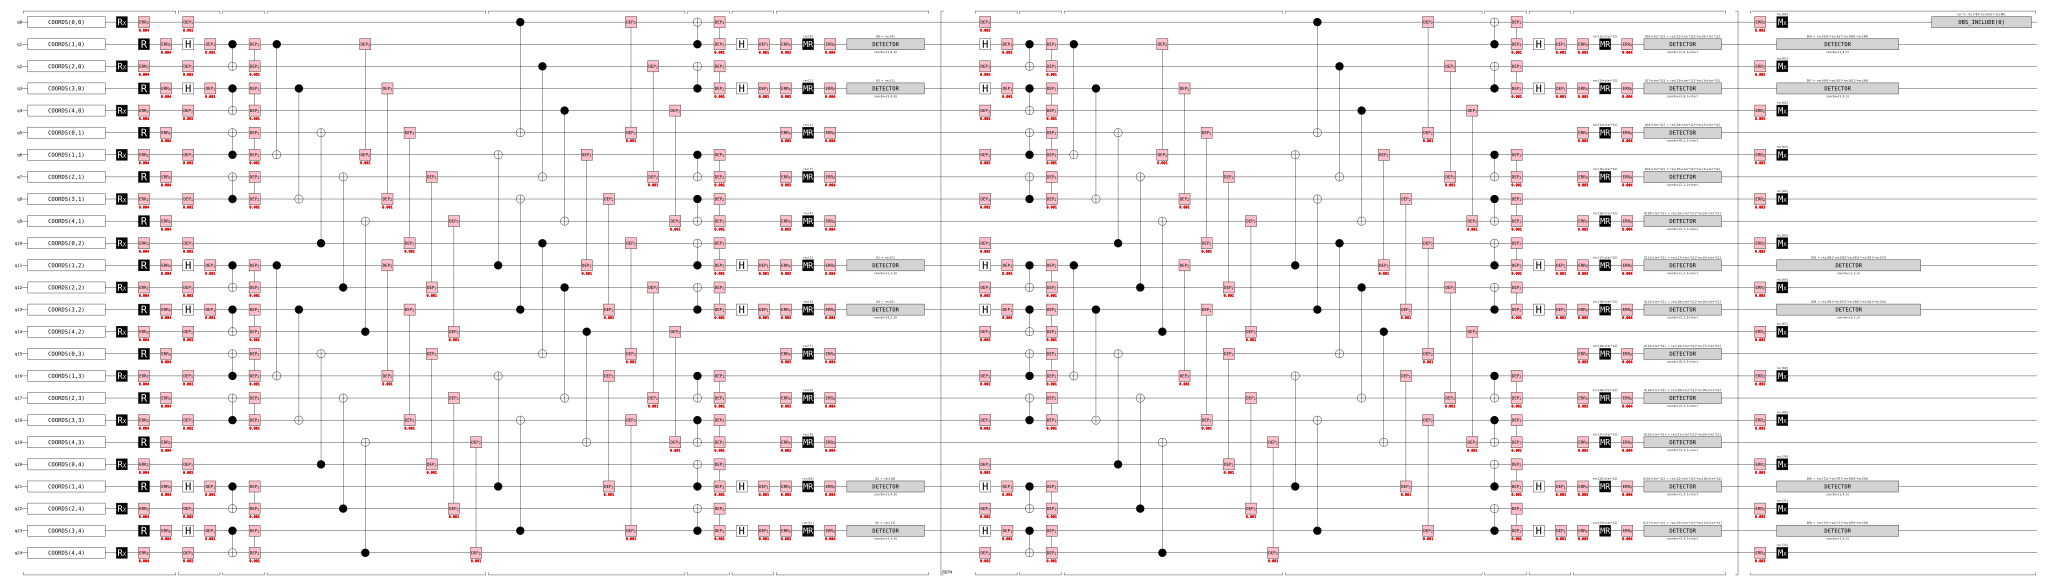

In [5]:
circuit.diagram('timeline-svg')

In [6]:
params = {
    "code_task": "surface_code:rotated_memory_x",
    "rounds": 1,
    "distance": 3,
    "after_clifford_depolarization": 0.001,
    "before_round_data_depolarization": 0.002,
    "before_measure_flip_probability": 0.003,
    "after_reset_flip_probability": 0.004,
}

In [7]:
circuit = sc.generate_circuit(**params)

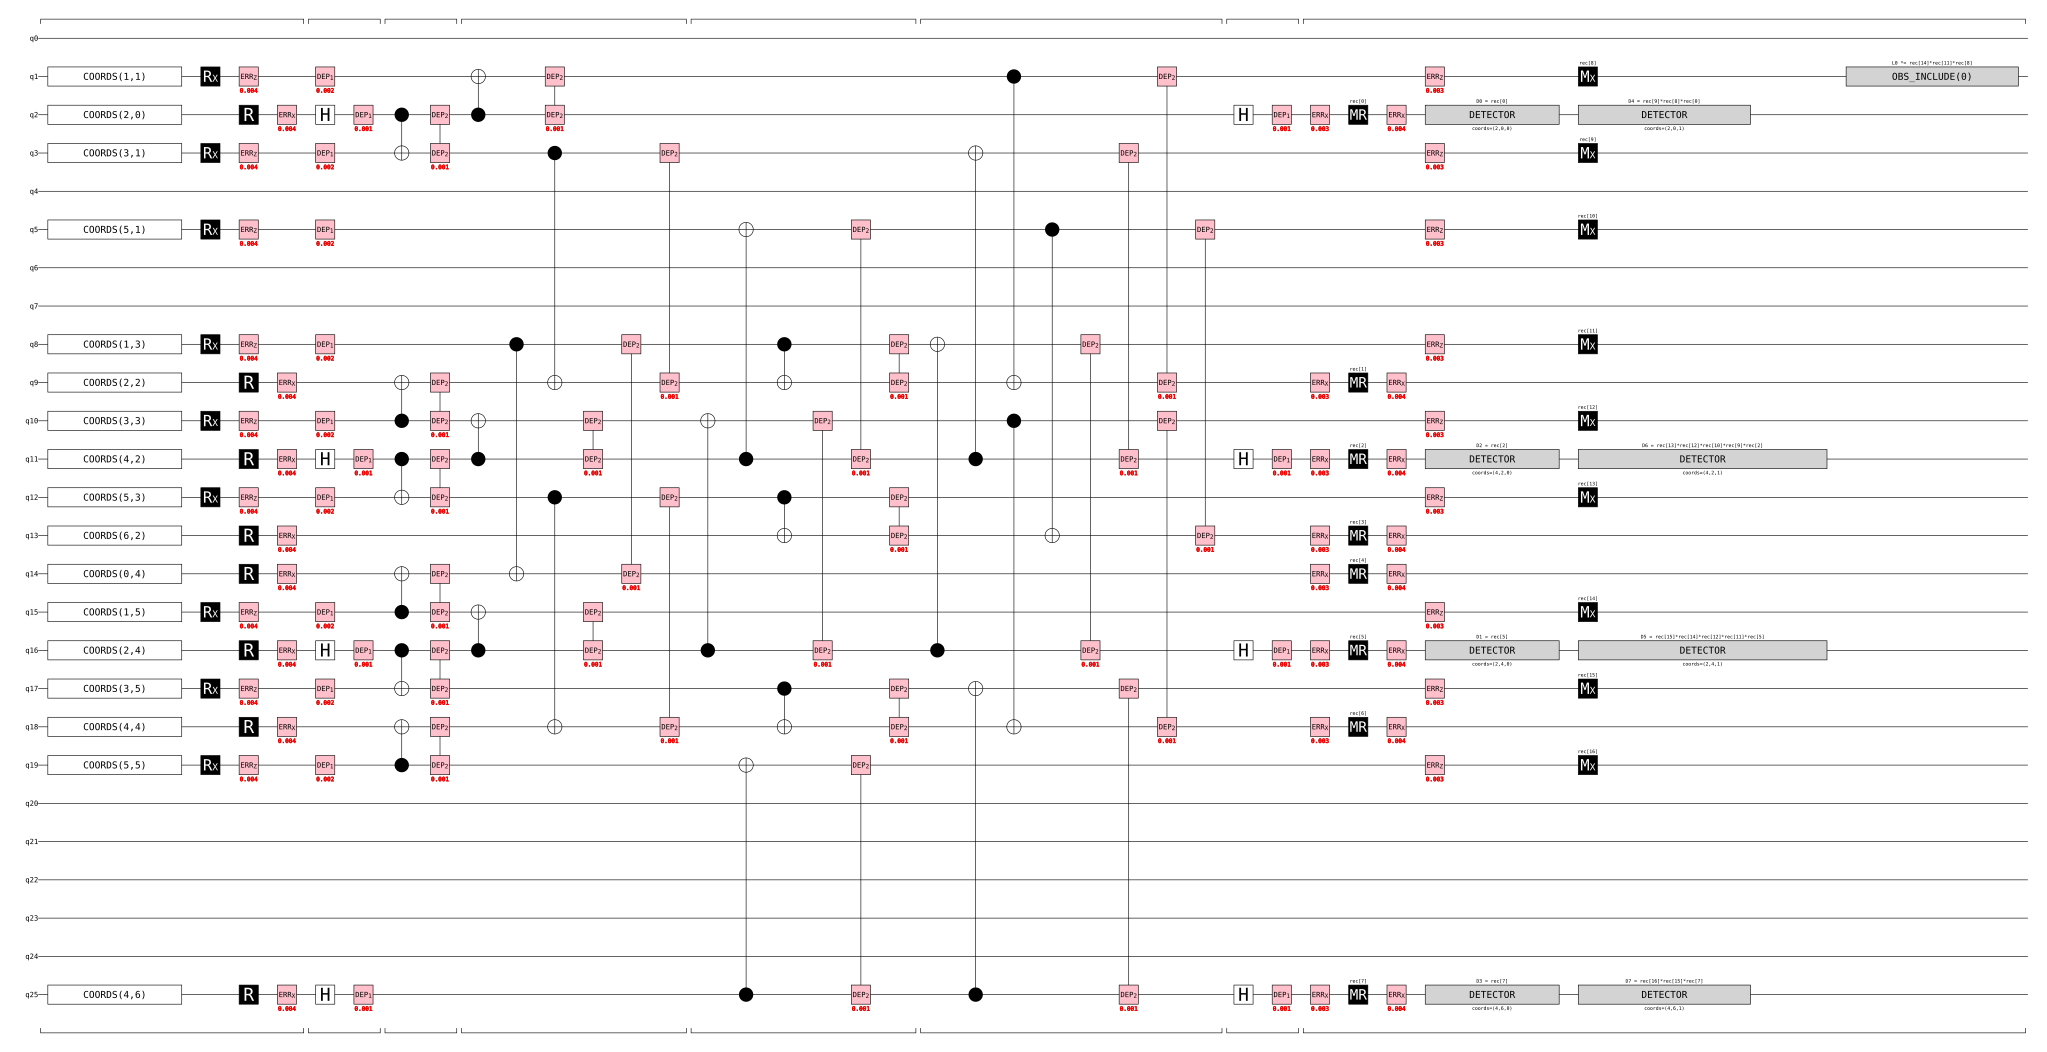

In [8]:
circuit.diagram('timeline-svg')

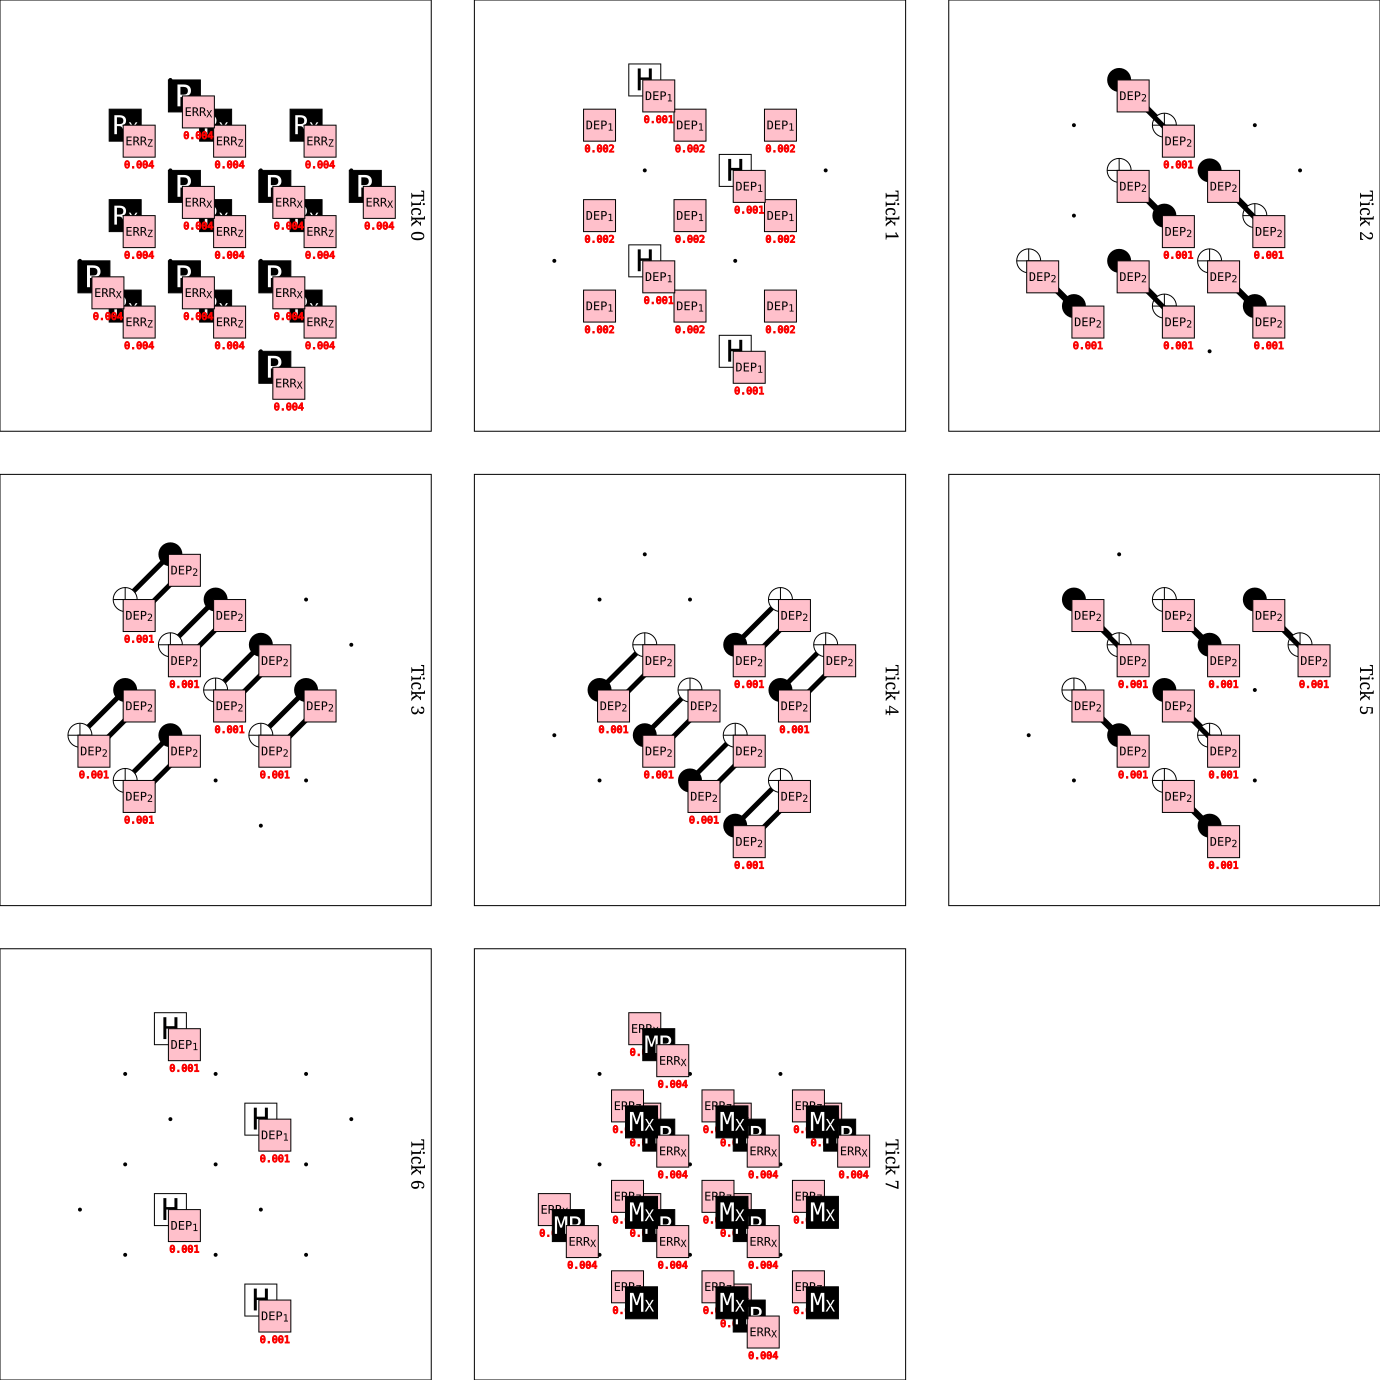

In [9]:
circuit.diagram('timeslice-svg')

In [10]:
detector_sampler = circuit.compile_detector_sampler()
one_sample = detector_sampler.sample(shots=1)[0]
print(len(one_sample))
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("!" if e else "_" for e in timeslice))

8
________


In [11]:
circuit_builder = sim.SurfaceCodeBuilder()

In [12]:
noise_params = {
    "after_clifford_depolarization": 0.001,
    "before_round_data_depolarization": 0.002,
    "before_measure_flip_probability": 0.003,
    "after_reset_flip_probability": 0.004,
}

there were 156 wrong predictions (logical errors) out of 100000 shots


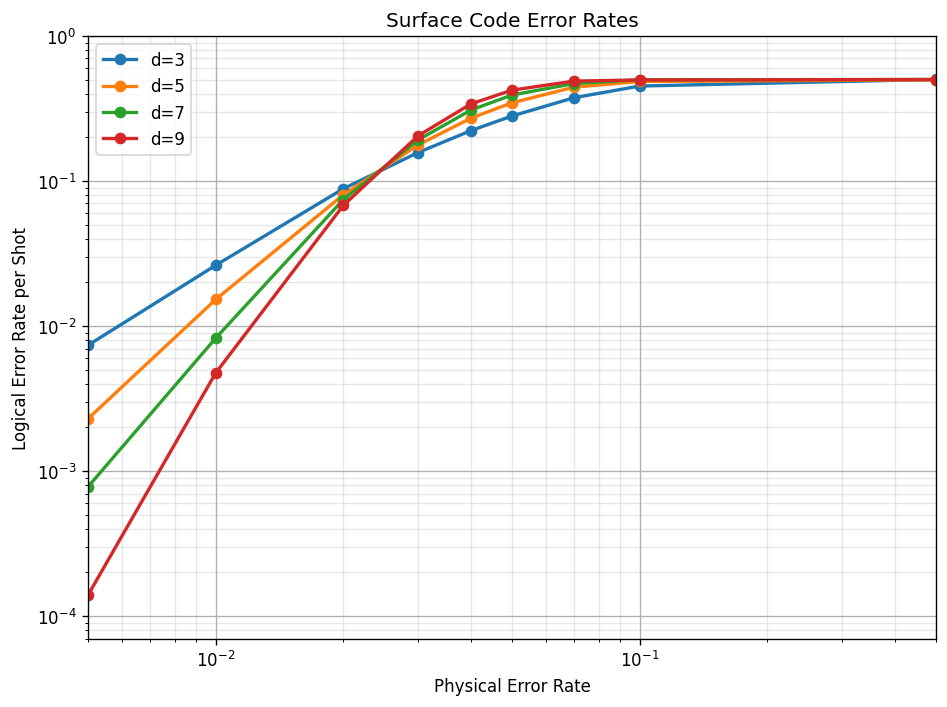

In [13]:
num_shots = 100_000
num_logical_errors = sim.count_logical_errors(circuit, num_shots)
print("there were", num_logical_errors, "wrong predictions (logical errors) out of", num_shots, "shots")
simulator = sim.SinisterSimulation(circuit_builder, max_shots=num_shots, noise_values=(0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.5), distances=(3, 5, 7, 9))
stats = simulator.run()


simulator.plot(stats, title="Surface Code")

In [ ]:
params_perfect = {
    "code_task": "surface_code:rotated_memory_z",
    "rounds": 1,
    "distance": 3,
}

In [24]:
perfect_circuit = sc.generate_circuit(**params_perfect)

In [33]:
import stim
import importlib
import simulation

importlib.reload(simulation)

# Inject an X error on the first qubit immediately after preparation,
# before the first syndrome-measurement round starts.
faulty_lines = str(perfect_circuit).splitlines()
for index, line in enumerate(faulty_lines):
    if line.startswith('TICK'):
        faulty_lines.insert(index, 'X 5')
        break

faulty_circuit = stim.Circuit('\n'.join(faulty_lines))

sample = simulation.sample_logical_errors(faulty_circuit, num_shots=5, return_weights=True)
print('detection events:')
print(sample.detection_events.astype(int))
print('observable flips:')
print(sample.observable_flips.astype(int))
print('weights:')
print(sample.weights)


detection events:
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
observable flips:
[[0]
 [0]
 [0]
 [0]
 [0]]
weights:
[0. 0. 0. 0. 0.]


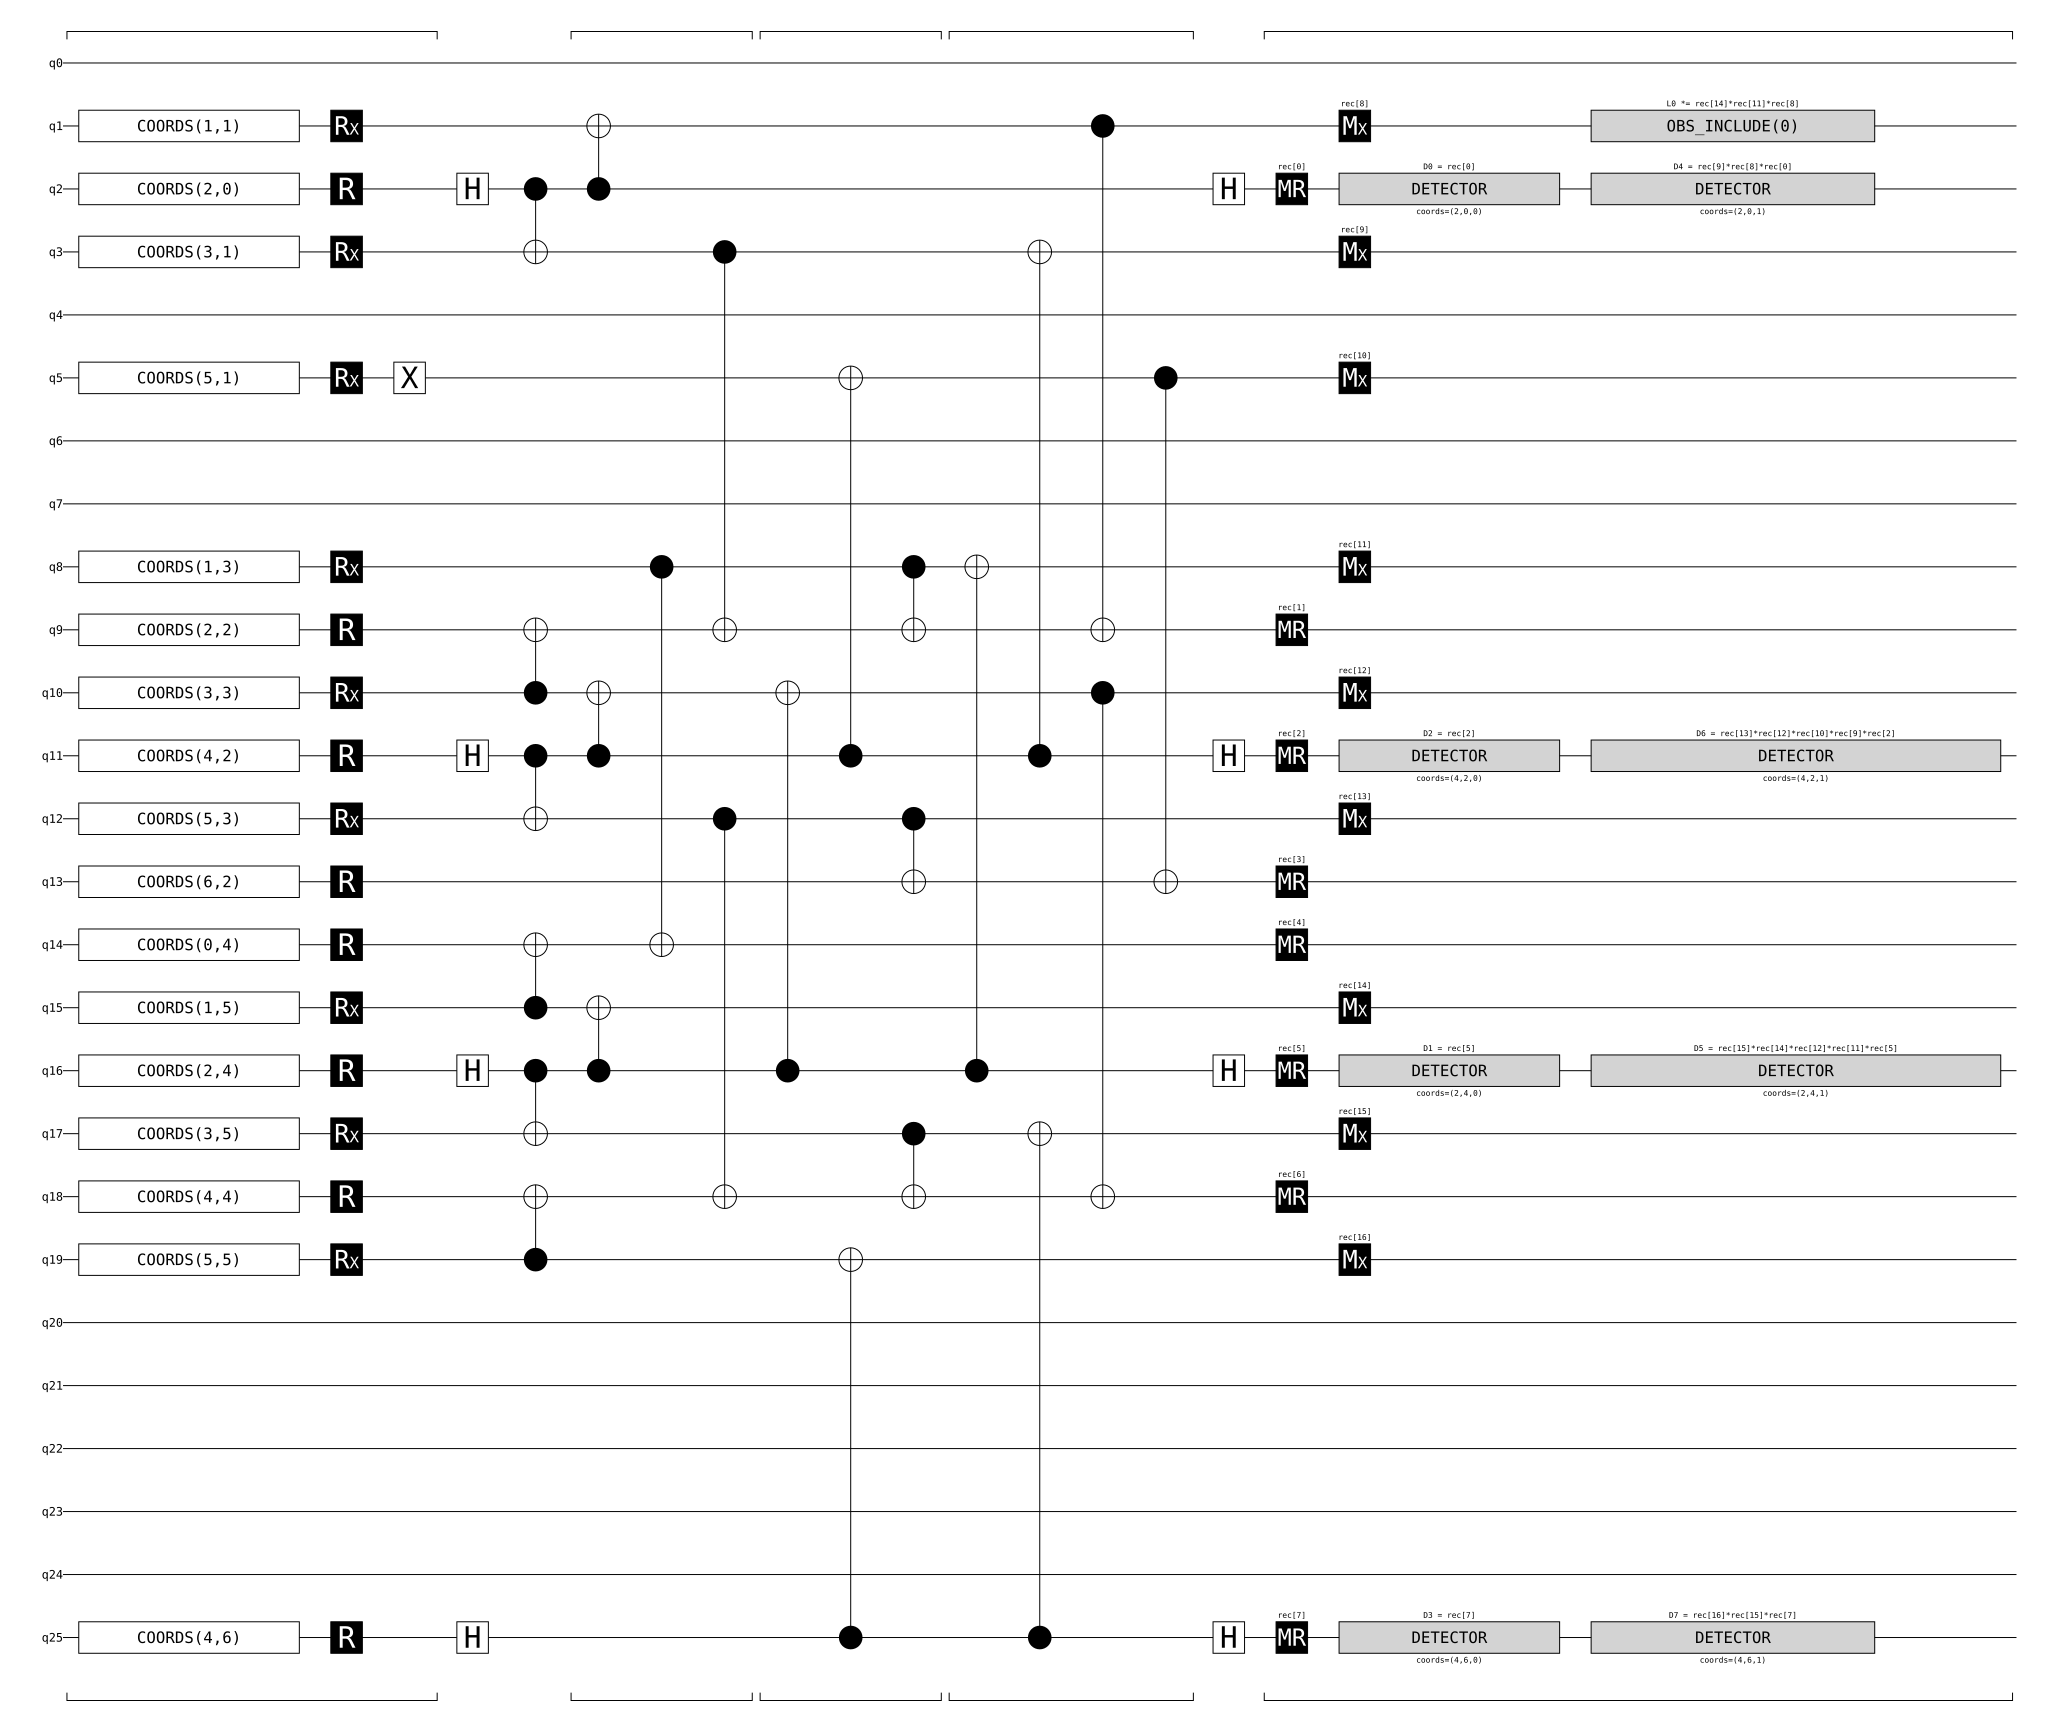

In [34]:
faulty_circuit.diagram('timeline-svg')

In [14]:
import importlib
import simulation

importlib.reload(simulation)

one_experiment = simulation.sample_logical_errors(circuit, num_shots=5, return_weights=True)
print('logical errors:', one_experiment.num_errors)
print('weights:', one_experiment.weights)
print('detection events:', one_experiment.detection_events)
print('observable flips:', one_experiment.observable_flips)


logical errors: 0
weights: [0.        0.        4.7460492 0.        0.       ]
detection events: [[False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False  True False]
 [False False False False False False False False]
 [False False False False False False False False]]
observable flips: [[False]
 [False]
 [False]
 [False]
 [False]]


In [15]:
import numpy as np
import importlib
import simulation

importlib.reload(simulation)

sample = simulation.sample_logical_errors(circuit, num_shots=20, return_weights=True)

# Each row is one shot; each column is one detector/stabilizer.
syndromes = sample.detection_events.astype(np.uint8)
unique_syndromes, inverse, counts = np.unique(
    syndromes,
    axis=0,
    return_inverse=True,
    return_counts=True,
)

print("syndromes", syndromes)

# Empirical measurement of Z_L

print('per-shot syndrome probabilities:')
print(shot_probabilities)
print('unique syndromes and their probabilities:')
for syndrome, prob in zip(unique_syndromes, syndrome_probabilities):
    print(syndrome.astype(int), prob)
print('decoder weights:')
print(sample.weights)


syndromes [[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 1]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
per-shot syndrome probabilities:


NameError: name 'shot_probabilities' is not defined

In [ ]:
import numpy as np
import importlib
import simulation

importlib.reload(simulation)

sample = simulation.sample_logical_errors(circuit, num_shots=20, return_weights=True)
syndromes = sample.detection_events.astype(np.uint8)
unique_syndromes, inverse, counts = np.unique(
    syndromes,
    axis=0,
    return_inverse=True,
    return_counts=True,
)

# Empirical probability of each unique syndrome in this batch.
syndrome_probabilities = counts / len(syndromes)
# Probability assigned to each shot based on the syndrome it landed in.
shot_probabilities = syndrome_probabilities[inverse]

# Replace this with your measured correlator for each shot or syndrome.
# Example: one value per shot, same length as shot_probabilities.
stabilizer_correlators = np.ones_like(shot_probabilities)

# Your estimator: sum_s P(s) * (1 - <Z_S^corr>_s) / 2
per_shot_terms = shot_probabilities * (1 - stabilizer_correlators) / 2
estimate = per_shot_terms.sum()

print('shot probabilities:')
print(shot_probabilities)
print('stabilizer correlators:')
print(stabilizer_correlators)
print('per-shot contribution:')
print(per_shot_terms)
print('estimator:')
print(estimate)


shot probabilities:
[0.9  0.05 0.9  0.9  0.9  0.9  0.9  0.9  0.9  0.9  0.05 0.9  0.9  0.9
 0.9  0.9  0.9  0.9  0.9  0.9 ]
stabilizer correlators:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
per-shot contribution:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
estimator:
0.0


In [ ]:
import numpy as np
import importlib
import simulation

importlib.reload(simulation)

sample = simulation.sample_logical_errors(circuit, num_shots=20, return_weights=True)

# Convert detector/stabilizer bits {0, 1} into correlators {+1, -1}.
# False/0 means the stabilizer is +1, True/1 means the stabilizer is -1.
stabilizer_correlators = 1 - 2 * sample.detection_events.astype(np.int8)
mean_stabilizer_correlators = stabilizer_correlators.mean(axis=0)

print('stabilizer correlators per shot:')
print(stabilizer_correlators)
print('mean stabilizer correlator for each stabilizer:')
print(mean_stabilizer_correlators)


stabilizer correlators per shot:
[[ 1  1  1  1  1  1  1  1]
 [ 1  1 -1  1  1 -1 -1 -1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [-1  1 -1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]
 [ 1 -1 -1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1]]
mean stabilizer correlator for each stabilizer:
[0.9 0.9 0.7 1.  1.  0.9 0.9 0.9]
